# Docling PDF Extraction Pipeline

This notebook demonstrates a **complete document intelligence pipeline** using Docling to parse a research-grade PDF into structured elements:

| Stage | What happens |
|---|---|
| **1. Setup** | Imports, paths, output directory scaffold |
| **2. Pipeline config** | TableFormer ACCURATE mode, image capture at 3× scale |
| **3. Conversion** | Docling converts PDF → DoclingDocument |
| **4. Page grouping** | Items are bucketed by page number |
| **5. Per-page processing** | Text, headings, lists, tables, figures extracted |
| **6. Figure analysis** | OpenAI GPT-4o vision describes each captured figure |
| **7. Table export** | Each table exported as CSV + Markdown |
| **8. Document assembly** | All pages stitched into one Markdown file |

In [1]:
# ============================================================
# CELL 1: Load Environment Variables
# ============================================================
# We store API keys (OpenAI, Anthropic, Google etc.) in a .env file
# so they are NEVER hard-coded in our notebooks or committed to Git.
#
# The .env file lives in the project root and looks like this:
#   OPENAI_API_KEY=sk-...
#   ANTHROPIC_API_KEY=sk-ant-...
#   GOOGLE_API_KEY=AI...
#
# load_dotenv() reads that file and injects those values into
# os.environ so that LangChain (and any other library) can find them
# automatically without us passing the key explicitly.
#
# Returns True if the .env file was found and loaded successfully.

from dotenv import load_dotenv

load_dotenv()

True

## Cell 1 – Imports

In [2]:
# ── Standard library ──────────────────────────────────────────────────────
import base64          # needed to encode figure PNGs for the OpenAI vision API
import io
from collections import defaultdict
from pathlib import Path

# ── Docling core ──────────────────────────────────────────────────────────
from docling.document_converter import DocumentConverter, PdfFormatOption, WordFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions, TableFormerMode
from docling.datamodel.base_models import InputFormat
from docling.datamodel.document import (
    TableItem,        # a parsed table (rows + columns)
    PictureItem,      # a figure / chart / image
    TextItem,         # a regular paragraph of text
    SectionHeaderItem,# section / sub-section headings
    ListItem,         # a bullet or numbered list entry
)

# ── Third-party ───────────────────────────────────────────────────────────
from openai import OpenAI   # GPT-4o vision for figure description
import pandas as pd          # table → DataFrame → CSV

## Cell 2 – Global configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
pdf_path = Path(
    "/Users/akellaprudhvi/mystuff/Course/GenAI-Course-Modules/"
    "Module_4_notebooks/docs/AI-Enablers-Adopters-research-report.pdf"
)

# Root directory where all extracted artefacts will be written
OUTPUT_DIR = Path("extracted_docs_bounded")

# ── Model ─────────────────────────────────────────────────────────────────
# Must be a vision-capable model — gpt-4o can accept base64 image inputs
OPENAI_MODEL = "gpt-4o"

# ── Image capture scale ───────────────────────────────────────────────────
# 3.0 × the native PDF resolution → high-DPI PNGs suitable for vision models
IMAGE_SCALE = 3.0

## Cell 3 – Output directory scaffold

In [4]:
# One sub-folder per PDF (named after the file stem) so multiple PDFs
# can be processed into the same OUTPUT_DIR without collisions.
doc_output_dir = OUTPUT_DIR / pdf_path.stem

# pages/   → one .md file per page (text content)
# figures/ → PNG images for every PictureItem Docling captures
# tables/  → CSV + Markdown for every TableItem
(doc_output_dir / "pages").mkdir(parents=True, exist_ok=True)
(doc_output_dir / "figures").mkdir(parents=True, exist_ok=True)
(doc_output_dir / "tables").mkdir(parents=True, exist_ok=True)

print(f"Output root: {doc_output_dir.resolve()}")

Output root: /Users/akellaprudhvi/mystuff/Course/GenAI-Course-Modules/Module_4_notebooks/layout_identification_extraction/extracted_docs_bounded/AI-Enablers-Adopters-research-report


## Cell 4 – Docling pipeline options & converter

In [5]:
# ── Pipeline options ───────────────────────────────────────────────────────
pipeline_options = PdfPipelineOptions()


# Render pages / crops at 3× resolution → cleaner PNGs for vision models
pipeline_options.images_scale = IMAGE_SCALE

# Save individual figure PNGs alongside the DoclingDocument
pipeline_options.generate_picture_images = True

# Also save table regions as PNGs (useful as a fallback when HTML export fails)
pipeline_options.generate_table_images = True

# Skip OCR — assume the PDF has embedded selectable text.
# Set do_ocr=True for scanned / image-only PDFs.
pipeline_options.do_ocr = False

# Enable the ML-based table structure detector (TableFormer)
pipeline_options.do_table_structure = True

# ACCURATE mode runs the full TableFormer model → best row/col detection
# Use TableFormerMode.FAST for quicker (but lower-quality) extraction
pipeline_options.table_structure_options.mode = TableFormerMode.ACCURATE

# ── Converter ──────────────────────────────────────────────────────────────
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)

    }
)

print("Converter ready.")

Converter ready.


## Cell 5 – Convert the PDF

In [6]:
# This is the heavy step — Docling runs layout analysis + TableFormer.
# Typical throughput: ~1-3 pages/sec depending on table density.
print(f"Converting: {pdf_path.name} …")
conv_result = converter.convert(pdf_path)

# DoclingDocument holds the full parse tree — pages, items, images, etc.
doc = conv_result.document

print(f"Done. Pages detected: {len(doc.pages)}")

Converting: AI-Enablers-Adopters-research-report.pdf …
Done. Pages detected: 7


self_ref='#/texts/1' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.SECTION_HEADER: 'section_header'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=711.342, r=104.062, b=697.655, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 9))] source=[] comments=[] orig='Thematics' text='Thematics' formatting=None hyperlink=None level=1
Level: 1=====
self_ref='#/texts/2' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.SECTION_HEADER: 'section_header'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=678.232, r=364.848, b=632.524, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 39))] source=[] comments=[] orig="Uncovering Alpha in AI's Rate of Change" text="Uncovering Alpha in AI's Rate of Change" formatting=None hyperlink=None level=1
Level: 1=====
self_ref='#/texts/3' parent=RefItem(cref='#/body') children
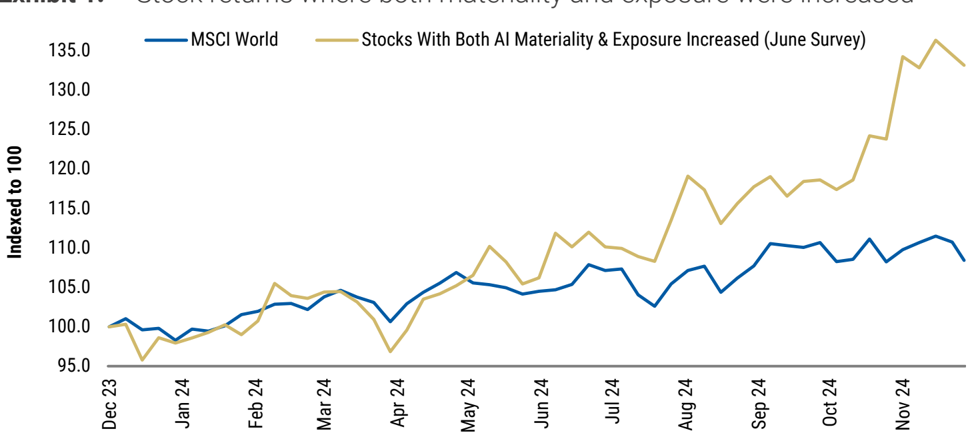
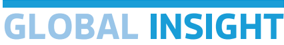
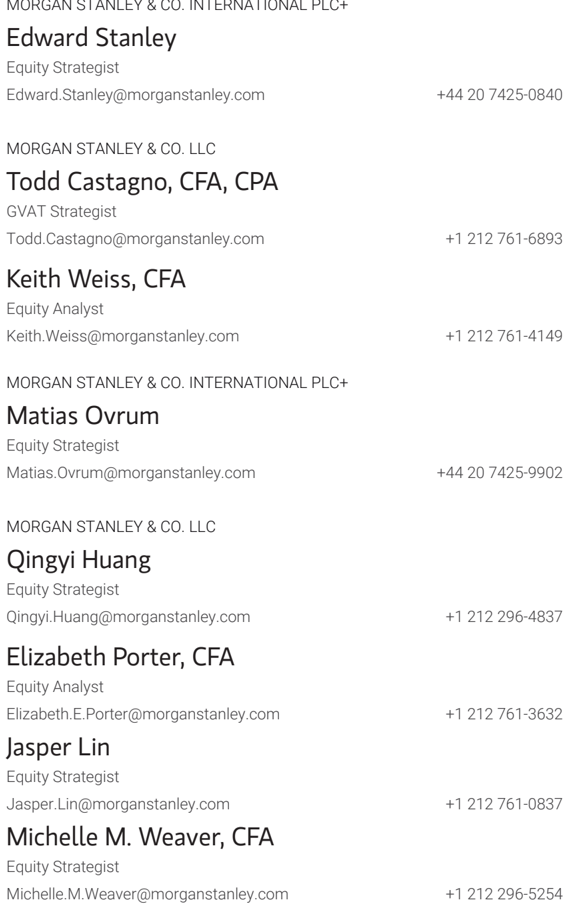

In [9]:
i = 0
for item,level in doc.iterate_items():
    print("=============================")
    print(item)
    print(f"Level: {level}""=====")
    i = i +1
    if i>10:
        break


In [40]:
len(list(doc.iterate_items()))

2

## Cell 6 – Group document items by page

(1, [{'item': SectionHeaderItem(self_ref='#/texts/1', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.SECTION_HEADER: 'section_header'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=711.342, r=104.062, b=697.655, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 9))], source=[], comments=[], orig='Thematics', text='Thematics', formatting=None, hyperlink=None, level=1), 'level': 1}, {'item': SectionHeaderItem(self_ref='#/texts/2', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.SECTION_HEADER: 'section_header'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=678.232, r=364.848, b=632.524, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 39))], source=[], comments=[], orig="Uncovering Alpha in AI's Rate of Change", text="Uncovering Alpha in AI's Rate of Change", formatting=None, hyperlink=N
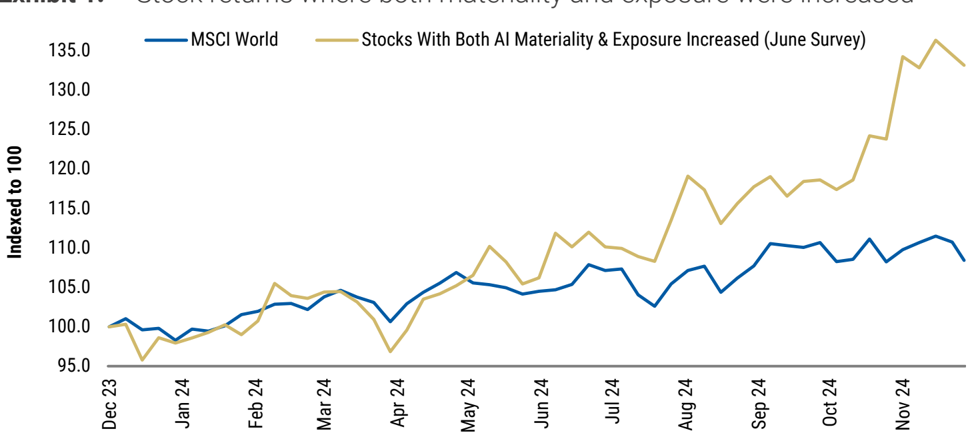
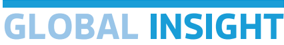
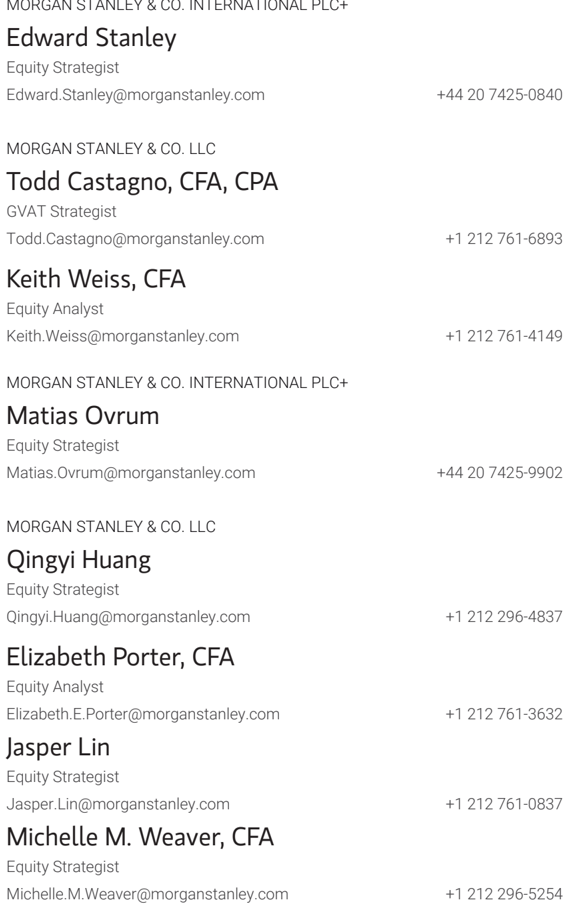

In [12]:
# doc.iterate_items() yields (item, level) pairs in reading order.
# We bucket them by page number so we can process / save page-by-page.

# pages_items: { page_no (int) → [{ 'item': ..., 'level': int }, ...] }
pages_items = defaultdict(list)

for item, level in doc.iterate_items():
    # prov (provenance) records the bounding box + page number.
    # Items without provenance are structural metadata — skip them.
    if not item.prov:
        continue
    page_num = item.prov[0].page_no
    pages_items[page_num].append({"item": item, "level": level})

print(list(pages_items.items())[0])
print(f"Pages with content: {sorted(pages_items.keys())}")

## Cell 7 – Helper: encode a PIL image as base64 for the OpenAI vision API

In [20]:
def pil_to_base64(pil_image, fmt: str = "PNG") -> str:
    """
    Encode a PIL Image to a base64 string.

    Parameters
    ----------
    pil_image : PIL.Image.Image
        The image returned by Docling's get_image() call.
    fmt : str
        Target encoding format, default 'PNG'. Use 'JPEG' for smaller payloads.

    Returns
    -------
    str
        Base64-encoded image bytes (no data-URI prefix).
    """
    buffer = io.BytesIO()
    pil_image.save(buffer, format=fmt)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def analyse_figure_with_gpt4o(openai_client: OpenAI, pil_image, figure_label: str) -> str:
    """
    Send a figure image to GPT-4o and get a structured description.

    Parameters
    ----------
    openai_client : OpenAI
        Authenticated OpenAI client instance.
    pil_image : PIL.Image.Image
        The figure to describe.
    figure_label : str
        Human-readable label used in the prompt (e.g. 'Figure 3, Page 7').

    Returns
    -------
    str
        GPT-4o's plain-text description of the figure.
    """
    b64 = pil_to_base64(pil_image)
    response = openai_client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            f"You are analysing {figure_label} extracted from a research PDF. "
                            "Describe what the figure shows: chart type, axes/labels, key "
                            "data points or trends, and any title or caption visible. "
                            "Be concise but precise."
                        ),
                    },
                    {
                        "type": "image_url",
                        # The OpenAI vision API accepts inline base64 images via this URI scheme
                        "image_url": {"url": f"data:image/png;base64,{b64}"},
                    },
                ],
            }
        ],
        max_tokens=400,
    )
    return response.choices[0].message.content.strip()

## Cell 8 – Per-page extraction loop

For each page we:
1. Walk every item in reading order
2. Append headings / text / lists to a Markdown accumulator
3. Export tables to CSV and Markdown
4. Save figure PNGs and call GPT-4o to describe them
5. Write the assembled page content to `pages/page_NNN.md`

In [21]:
# ── OpenAI client (reads OPENAI_API_KEY from environment by default) ───────
openai_client = OpenAI()

# Counters to generate unique filenames across all pages
figure_counter = 0
table_counter  = 0

# Holds (page_no, markdown_text) for the final document assembly step
all_pages_markdown: list[tuple[int, str]] = []

# ─────────────────────────────────────────────────────────────────────────
for page_num in sorted(pages_items.keys()):
    items = pages_items[page_num]

    # Markdown lines accumulated for this page
    page_md_lines: list[str] = [f"## Page {page_num}\n"]

    for idx, entry in enumerate(items):
        item  = entry["item"]
        level = entry["level"]   # nesting depth in the document outline

        # ── Section headings ─────────────────────────────────────────────
        if isinstance(item, SectionHeaderItem):
            # Map Docling's heading level to Markdown # depth (capped at ######)
            hashes = "#" * min(level + 2, 6)   # +2 so top-level → ###
            page_md_lines.append(f"{hashes} {item.text}\n")

        # ── Body text ─────────────────────────────────────────────────────
        elif isinstance(item, TextItem):
            # Append as a plain paragraph followed by a blank line
            page_md_lines.append(f"{item.text}\n")

        # ── List items ────────────────────────────────────────────────────
        elif isinstance(item, ListItem):
            # Indent nested list items by 2 spaces per level beyond the first
            indent = "  " * max(0, level - 1)
            page_md_lines.append(f"{indent}- {item.text}\n")

        # ── Figures / charts / images ─────────────────────────────────────
        elif isinstance(item, PictureItem):
            figure_counter += 1
            fig_label  = f"Figure {figure_counter}, Page {page_num}"
            fig_stem   = f"figure_{figure_counter:03d}_page_{page_num:03d}"
            png_path   = doc_output_dir / "figures" / f"{fig_stem}.png"

            # get_image() returns (PIL.Image, mime_type); scale was set globally
            pil_img = item.get_image(doc)

            if pil_img is not None:
                # Persist the figure PNG to disk
                pil_img.save(png_path)

                # ── GPT-4o vision analysis ─────────────────────────────────
                print(f"  Analysing {fig_label} with GPT-4o …")
                description = analyse_figure_with_gpt4o(openai_client, pil_img, fig_label)

                # Embed figure reference + AI description in the page Markdown
                rel_img_path = f"../figures/{png_path.name}"
                page_md_lines.append(
                    f"\n![{fig_label}]({rel_img_path})\n"
                    f"**Figure description (GPT-4o):** {description}\n"
                )
            else:
                # Docling couldn't capture the image (e.g., vector-only figure)
                page_md_lines.append(f"\n*[{fig_label}: image not captured]*\n")

        # ── Tables ────────────────────────────────────────────────────────
        elif isinstance(item, TableItem):
            table_counter += 1
            tbl_label = f"Table {table_counter}, Page {page_num}"
            tbl_stem  = f"table_{table_counter:03d}_page_{page_num:03d}"

            # ── Export as CSV using pandas ─────────────────────────────────
            # export_to_dataframe() converts the TableFormer grid to a DataFrame
            try:
                df: pd.DataFrame = item.export_to_dataframe()
                csv_path = doc_output_dir / "tables" / f"{tbl_stem}.csv"
                df.to_csv(csv_path, index=False)

                # ── Also render to Markdown for inline display ─────────────
                md_table = df.to_markdown(index=False)  # requires tabulate
                page_md_lines.append(
                    f"\n**{tbl_label}**\n\n{md_table}\n"
                    f"*Exported to: {csv_path}*\n"
                )
            except Exception as exc:
                # Gracefully fall back if the table has no usable grid
                page_md_lines.append(
                    f"\n*[{tbl_label}: export failed — {exc}]*\n"
                )

    # ── Write per-page Markdown file ─────────────────────────────────────
    page_md_text = "\n".join(page_md_lines)
    page_file    = doc_output_dir / "pages" / f"page_{page_num:03d}.md"
    page_file.write_text(page_md_text, encoding="utf-8")

    # Store for final assembly
    all_pages_markdown.append((page_num, page_md_text))
    print(f"  ✓ Page {page_num:3d} saved → {page_file.name}")

print(f"\nExtraction complete: {table_counter} tables, {figure_counter} figures.")

  Analysing Figure 1, Page 1 with GPT-4o …
  Analysing Figure 2, Page 1 with GPT-4o …


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


  ✓ Page   1 saved → page_001.md
  Analysing Figure 3, Page 2 with GPT-4o …
  Analysing Figure 4, Page 2 with GPT-4o …
  Analysing Figure 5, Page 2 with GPT-4o …
  Analysing Figure 6, Page 2 with GPT-4o …
  ✓ Page   2 saved → page_002.md
  Analysing Figure 7, Page 3 with GPT-4o …
  Analysing Figure 8, Page 3 with GPT-4o …
  Analysing Figure 9, Page 3 with GPT-4o …
  Analysing Figure 10, Page 3 with GPT-4o …
  Analysing Figure 11, Page 3 with GPT-4o …
  Analysing Figure 12, Page 3 with GPT-4o …
  ✓ Page   3 saved → page_003.md
  Analysing Figure 13, Page 4 with GPT-4o …
  ✓ Page   4 saved → page_004.md
  Analysing Figure 14, Page 5 with GPT-4o …
  Analysing Figure 15, Page 5 with GPT-4o …
  ✓ Page   5 saved → page_005.md
  Analysing Figure 16, Page 6 with GPT-4o …


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


  Analysing Figure 17, Page 6 with GPT-4o …
  ✓ Page   6 saved → page_006.md
  Analysing Figure 18, Page 7 with GPT-4o …


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


  ✓ Page   7 saved → page_007.md

Extraction complete: 3 tables, 18 figures.


## Cell 9 – Assemble the full document Markdown

In [22]:
# Concatenate all page Markdown files in page order into a single document.
# This is useful as a RAG ingestion artefact or for LLM summarisation.

divider = "\n\n---\n\n"   # horizontal rule between pages

full_doc_md = divider.join(
    page_md for _, page_md in sorted(all_pages_markdown, key=lambda t: t[0])
)

# Prepend a title block with basic document metadata
header = (
    f"# {pdf_path.stem}\n\n"
    f"*Source:* `{pdf_path.name}`  \n"
    f"*Pages:* {len(all_pages_markdown)}  \n"
    f"*Tables extracted:* {table_counter}  \n"
    f"*Figures extracted:* {figure_counter}\n\n"
)

full_md_path = doc_output_dir / f"{pdf_path.stem}_full.md"
full_md_path.write_text(header + full_doc_md, encoding="utf-8")

print(f"Full document Markdown written to:\n  {full_md_path.resolve()}")
print(f"Total characters: {len(full_doc_md):,}")

Full document Markdown written to:
  /Users/akellaprudhvi/mystuff/Course/GenAI-Course-Modules/Module_4_notebooks/layout_identification_extraction/extracted_docs_bounded/AI-Enablers-Adopters-research-report/AI-Enablers-Adopters-research-report_full.md
Total characters: 32,908


## Cell 10 – Quick sanity-check preview

In [23]:
# Print a summary of what was extracted and show the first 1500 characters
# of the assembled document as a quick visual check.

print("=" * 60)
print("EXTRACTION SUMMARY")
print("=" * 60)
print(f"PDF          : {pdf_path.name}")
print(f"Pages        : {len(all_pages_markdown)}")
print(f"Tables found : {table_counter}")
print(f"Figures found: {figure_counter}")
print(f"Output root  : {doc_output_dir.resolve()}")
print()
print("── First 1500 chars of assembled document ──")
print(full_doc_md[:1500])

EXTRACTION SUMMARY
PDF          : AI-Enablers-Adopters-research-report.pdf
Pages        : 7
Tables found : 3
Figures found: 18
Output root  : /Users/akellaprudhvi/mystuff/Course/GenAI-Course-Modules/Module_4_notebooks/layout_identification_extraction/extracted_docs_bounded/AI-Enablers-Adopters-research-report

── First 1500 chars of assembled document ──
## Page 1

### Thematics

### Uncovering Alpha in AI's Rate of Change

More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.

AI's Rate of Change Continues to Surprise: Our first AI Adopter survey was published in January 2024, our second in June 2024. This is our third such analysis. We have been surprised by the continued extent of changes made by our analysts across >3,700 global stocks under coverag